# TM10007 Machine Learning Group 10 Liver 

In [2]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [146]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from scipy.stats import zscore, shapiro
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [4]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [5]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [93]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [ ]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423
(148,)


In [ ]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%
(148,)


### Scaling the data

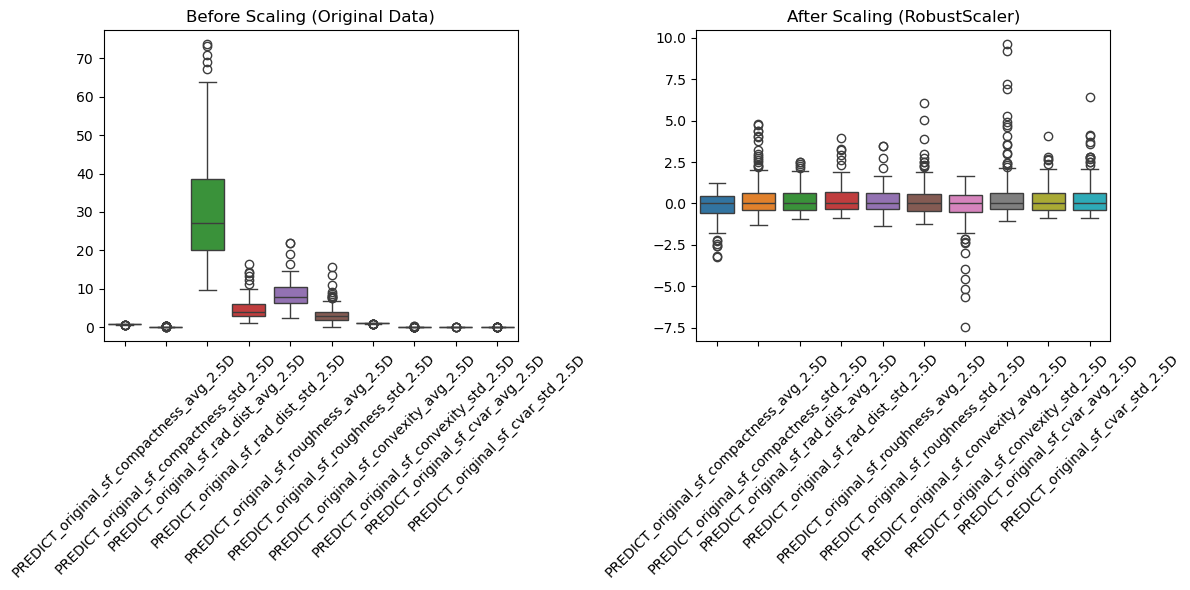

In [97]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Removing data with zero variance

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Keep only numeric columns (if not already done)
X_train_scaled = X_train_scaled.select_dtypes(include=[np.number])
X_test_scaled = X_test_scaled.select_dtypes(include=[np.number])

# Only apply VarianceThreshold if any features have zero variance
zv_selector = VarianceThreshold(threshold=0)
zv_selector.fit(X_train_scaled)
support_mask = zv_selector.get_support()

n_removed = len(support_mask) - sum(support_mask)

if n_removed > 0:
    X_train_scaled = pd.DataFrame(zv_selector.transform(X_train_scaled), columns=X_train_scaled.columns[support_mask])
    X_test_scaled = pd.DataFrame(zv_selector.transform(X_test_scaled), columns=X_test_scaled.columns[support_mask])
    print(f"Number of features removed due to zero variance: {n_removed}")
else:
    print("No features with zero variance found — skipping removal.")

Number of features removed due to zero variance: 17
(148,)


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


## Remove constant features

In [99]:
# Remove constant features
remove_indices = [84, 90, 412, 425, 438] # Indices to remove
if X_train_scaled.shape[1]>475:
    X_train_scaled = X_train_scaled.drop(X_train_scaled.columns[remove_indices], axis=1)
    X_test_scaled = X_test_scaled.drop(X_test_scaled.columns[remove_indices], axis=1)
    print(f"Number of features removed due to constant values: {len(remove_indices)}")
    print(f"Number of features after removal: {X_train_scaled.shape[1]}")
else:
    print("No features with constant values found — skipping removal.")
    print(f"Number of features after removal: {X_train_scaled.shape[1]}")

Number of features removed due to constant values: 5
Number of features after removal: 471


## Comparing feature selection methods for basic classifiers


=== Evaluating for k = 20 features ===

--- Method: PCA ---
Model: LDA
Model: QDA
Model: DT
Model: NB
Model: LR


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


--- Method: SelectKBest (F-Score) ---
Model: LDA
Model: QDA
Model: DT
Model: NB
Model: LR

--- Method: SelectKBest (Mutual Info) ---
Model: LDA
Model: QDA
Model: DT
Model: NB
Model: LR


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Method: GreedyForward ---
Model: LDA
Model: QDA


...


--- Method: RFE ---
Model: LDA
Model: QDA
[RFE - QDA] No valid folds — skipping.
Model: DT
Model: NB
[RFE - NB] No valid folds — skipping.
Model: LR


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


--- Method: Lasso ---
Model: LDA
Model: QDA


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


Model: DT
Model: NB
Model: LR


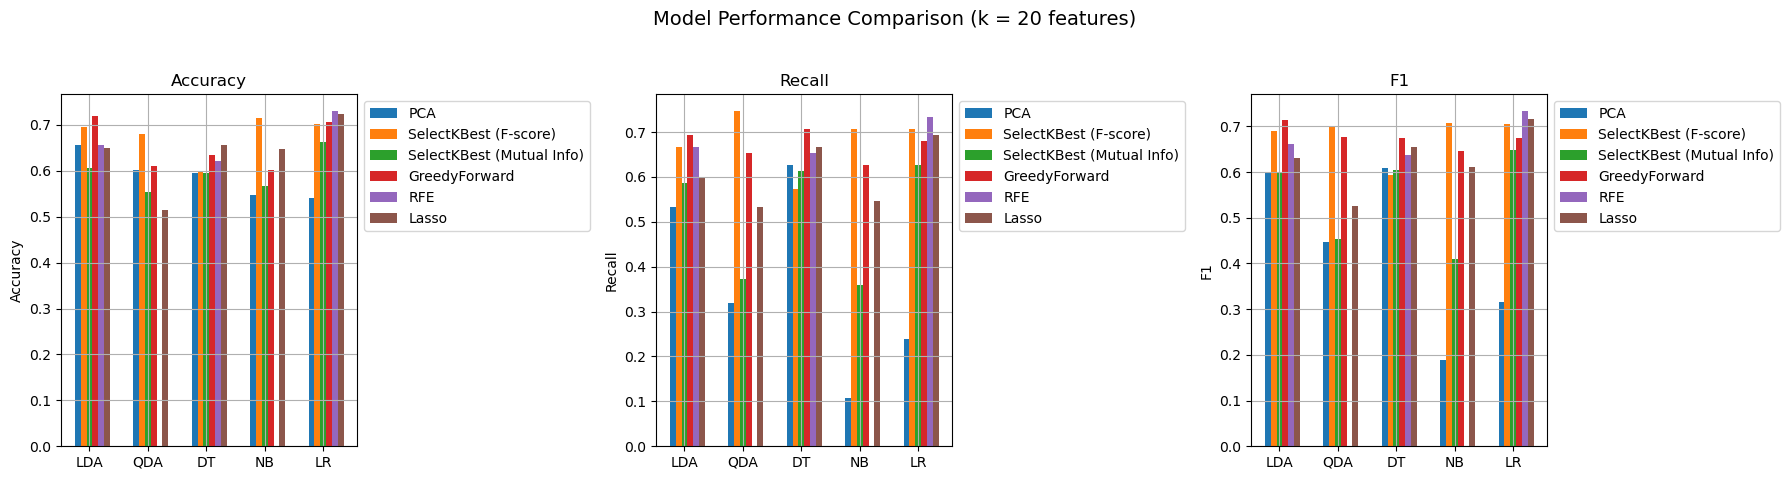

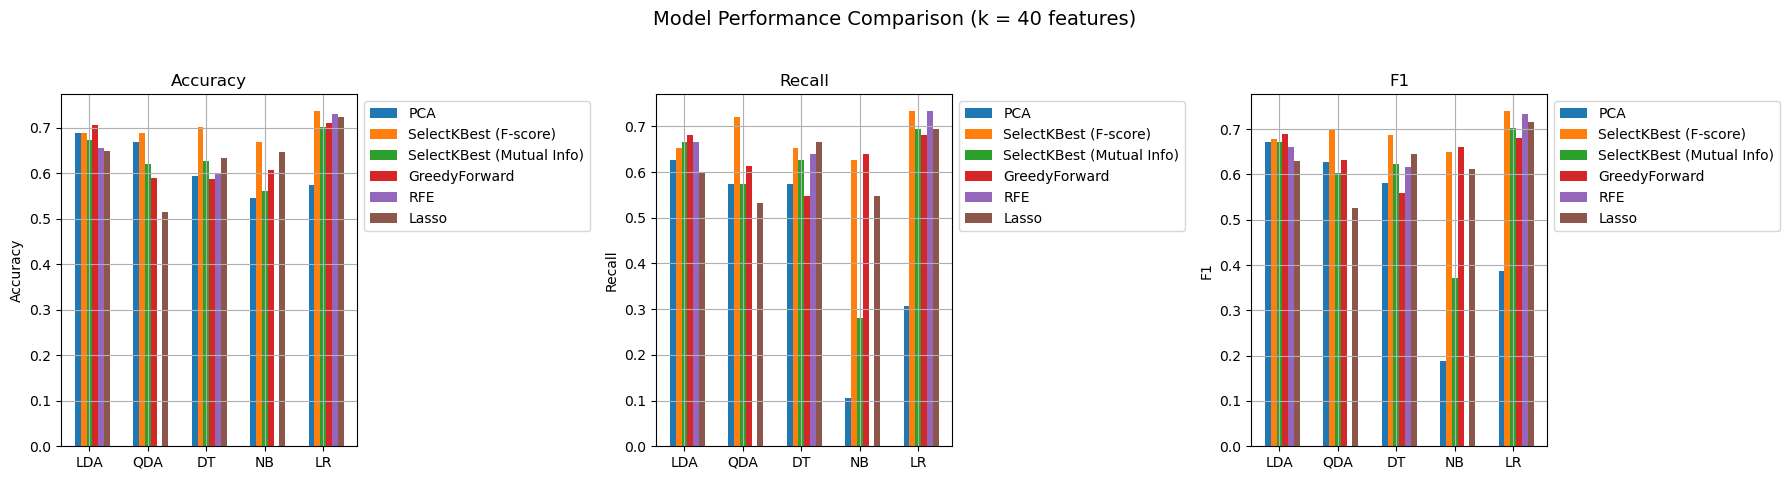

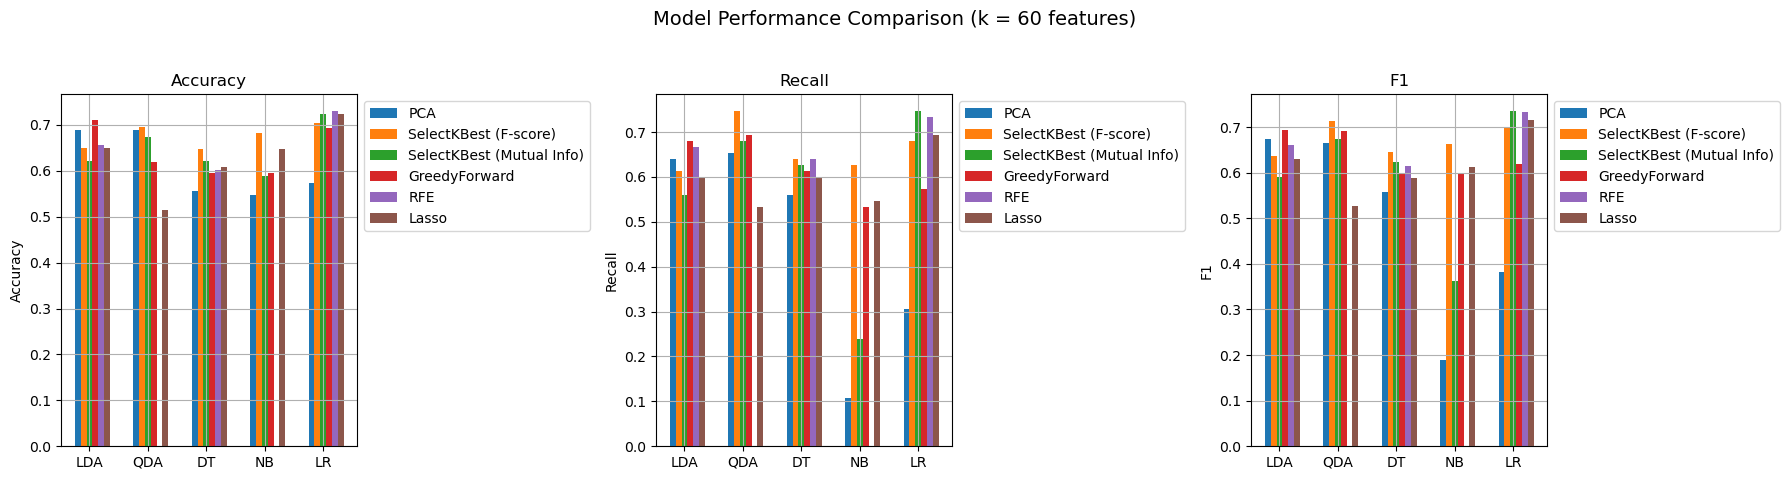

In [ ]:


# Models to test
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.001),
    "DT": DecisionTreeClassifier(),
    "NB": GaussianNB(),
    "LR": LogisticRegression(),
}

kf = StratifiedKFold(n_splits=5, shuffle=True)
k_values = [20,40,60]

# Store results
results = {
    k: {
        method: {model: {} for model in models}
        for method in ["PCA", "SelectKBest (F-Score)", "SelectKBest (Mutual Info)", "GreedyForward", "RFE", "Lasso"]
    }
    for k in k_values
}

for k in k_values:
    print(f"\n=== Evaluating for k = {k} features ===")

    for method_name in ["PCA", "SelectKBest (F-Score)", "SelectKBest (Mutual Info)", "GreedyForward", "RFE", "Lasso"]:
        print(f"\n--- Method: {method_name} ---")

        for model_name, model in models.items():
            print(f"Model: {model_name}")

            accuracies, recalls, f1s = [], [], []
            for train_idx, test_idx in kf.split(X_train_scaled, y_train):
        
                X_fold_train, X_fold_test = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[test_idx]
                y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
                if method_name == "PCA":
                    reducer = PCA(n_components=k)
                    X_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                    X_test_reduced = reducer.transform(X_fold_test)

                elif method_name == "SelectKBest (F-Score)":
                    reducer = SelectKBest(f_classif, k=k)
                    X_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                    X_test_reduced = reducer.transform(X_fold_test)

                elif method_name == "SelectKBest (Mutual Info)":
                    reducer = SelectKBest(mutual_info_classif, k=k)
                    X_train_reduced = reducer.fit_transform(X_fold_train, y_fold_train)
                    X_test_reduced = reducer.transform(X_fold_test)

                elif method_name == "GreedyForward":
                    selector = SelectKBest(f_classif, k=k)
                    X_fold_train_uni = selector.fit_transform(X_fold_train, y_fold_train)
                    feature_names = X_train_scaled.columns[selector.get_support()]
                    X_fold_train_df = pd.DataFrame(X_fold_train_uni, columns=feature_names)

                    selected_features = []
                    remaining_features = list(feature_names)
                    best_score = -np.inf
                    patience = 2
                    no_improve = 0

                    while remaining_features and no_improve < patience:
                        local_best_score = -np.inf
                        local_best_feature = None

                        for feature in remaining_features:
                            trial_features = selected_features + [feature]
                            X_trial = X_fold_train_df[trial_features]
                            score = cross_val_score(clone(model), X_trial, y_fold_train,
                                                    cv=3, scoring='accuracy').mean()
                            if score > local_best_score:
                                local_best_score = score
                                local_best_feature = feature

                        if local_best_score > best_score:
                            best_score = local_best_score
                            selected_features.append(local_best_feature)
                            remaining_features.remove(local_best_feature)
                            no_improve = 0
                        else:
                            no_improve += 1
                
                    X_train_reduced = X_fold_train_df[selected_features]
                    X_test_reduced = pd.DataFrame(selector.transform(X_fold_test), columns=feature_names)[selected_features]
            
                elif method_name in ["RFE", "Lasso"]:
                    if method_name == "RFE":
                        # Apply RFE (Recursive Feature Elimination) for LDA and Decision Tree
                        if model_name in ["LDA", "DT", "LR"]:
                            selector = RFE(estimator=clone(model))
                            X_train_reduced = selector.fit_transform(X_fold_train, y_fold_train)
                            X_test_reduced = selector.transform(X_fold_test)
                        else:
                            continue
        
                    elif method_name == "Lasso":
                        # Now first use the selectfrom model module. Select all features with a weight above the median.
                        selector = SelectFromModel(estimator=Lasso(alpha=10**(-10)), threshold='median')
                        selector.fit(X_fold_train, y_fold_train)
                        X_train_reduced = selector.transform(X_fold_train)
                        X_test_reduced = selector.transform(X_fold_test)

                model_clone = clone(model)
                model_clone.fit(X_train_reduced, y_fold_train)
                y_pred = model_clone.predict(X_test_reduced)

                accuracies.append(accuracy_score(y_fold_test, y_pred))
                recalls.append(recall_score(y_fold_test, y_pred))
                f1s.append(f1_score(y_fold_test, y_pred))

            if len(accuracies) == 0:
                print(f"[{method_name} - {model_name}] No valid folds — skipping.")
                continue
            
            results[k][method_name][model_name] = {
                "accuracy": np.mean(accuracies),
                "recall": np.mean(recalls),
                "f1": np.mean(f1s)
            }

# === Plot comparison in subplots ===
metrics = ["accuracy", "recall", "f1"]
num_metrics = len(metrics)

for k in k_values:
    fig, axes = plt.subplots(1, num_metrics, figsize=(18, 5))
    fig.suptitle(f'Model Performance Comparison (k = {k} features)', fontsize=14)

    for i, metric in enumerate(metrics):
        labels = list(models.keys())
        x = np.arange(len(labels))
        width = 0.1

        pca_scores = [results[k]["PCA"][label][metric] for label in labels]
        skb_scores = [results[k]["SelectKBest (F-Score)"][label][metric] for label in labels]
        mi_scores = [results[k]["SelectKBest (Mutual Info)"][label][metric] for label in labels]
        greedy_scores = [results[k]["GreedyForward"][label][metric] for label in labels]
        rfe_scores = [results[k]["RFE"].get(label, {}).get(metric, np.nan) for label in labels]
        lasso_scores = [results[k]["Lasso"].get(label, {}).get(metric, np.nan) for label in labels]

        axes[i].bar(x - 2 * width, pca_scores, width, label='PCA')
        axes[i].bar(x - width, skb_scores, width, label='SelectKBest (F-score)')
        axes[i].bar(x, mi_scores, width, label='SelectKBest (Mutual Info)')
        axes[i].bar(x + width, greedy_scores, width, label='GreedyForward')
        axes[i].bar(x + 2 * width, rfe_scores, width, label='RFE')
        axes[i].bar(x + 3 * width, lasso_scores, width, label='Lasso')

        axes[i].set_ylabel(f'{metric.title()}')
        axes[i].set_title(metric.title())
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(labels)
        axes[i].legend()
        axes[i].grid(True)

        axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plt.show()

## Function Greedy forward

In [147]:

def greedy_forward_selection(X_fold_train, y_fold_train, X_fold_test, y_fold_test, k, model):
    selector = SelectKBest(f_classif, k=k)
    X_fold_train_uni = selector.fit_transform(X_fold_train, y_fold_train)
    feature_names = X_train_scaled.columns[selector.get_support()]
    X_fold_train_df = pd.DataFrame(X_fold_train_uni, columns=feature_names)

    selected_features = []
    remaining_features = list(feature_names)
    best_score = -np.inf
    patience = 2
    no_improve = 0

    while remaining_features and no_improve < patience:
        local_best_score = -np.inf
        local_best_feature = None

        for feature in remaining_features:
            trial_features = selected_features + [feature]
            X_trial = X_fold_train_df[trial_features]
            score = cross_val_score(clone(model), X_trial, y_fold_train,
                                    cv=3, scoring='accuracy').mean()
            if score > local_best_score:
                local_best_score = score
                local_best_feature = feature

        if local_best_score > best_score:
            best_score = local_best_score
            selected_features.append(local_best_feature)
            remaining_features.remove(local_best_feature)
            no_improve = 0
        else:
            no_improve += 1
    X_train_reduced = X_fold_train_df[selected_features]
    X_test_reduced = pd.DataFrame(selector.transform(X_fold_test), columns=feature_names)[selected_features]

  
    return selected_features, X_train_reduced, X_test_reduced

### Feature selection

#### SelectKbest top feature selection for SVM and kNN

(148,)

Evaluating kNN...


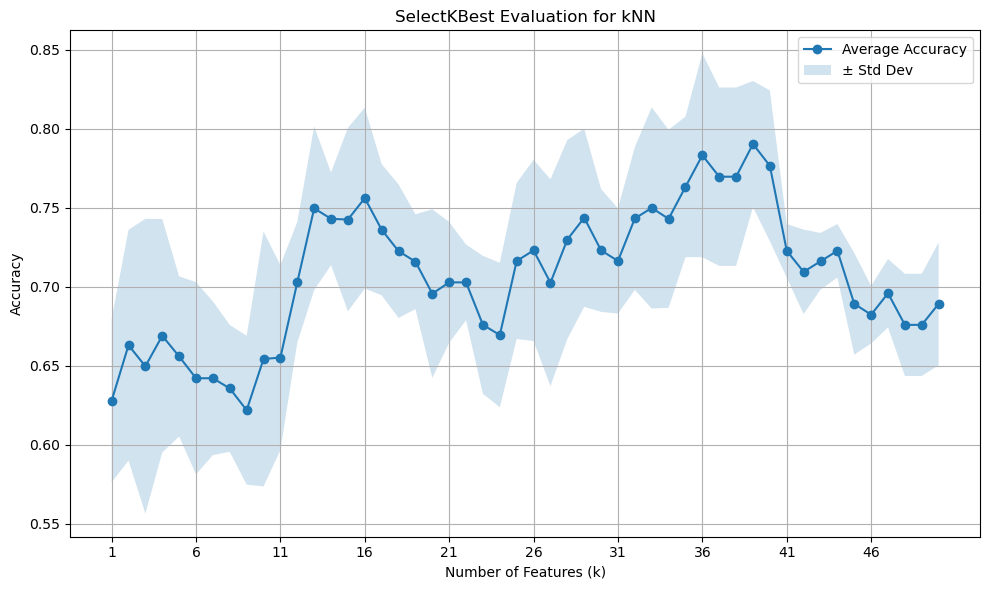


Evaluating SVM...


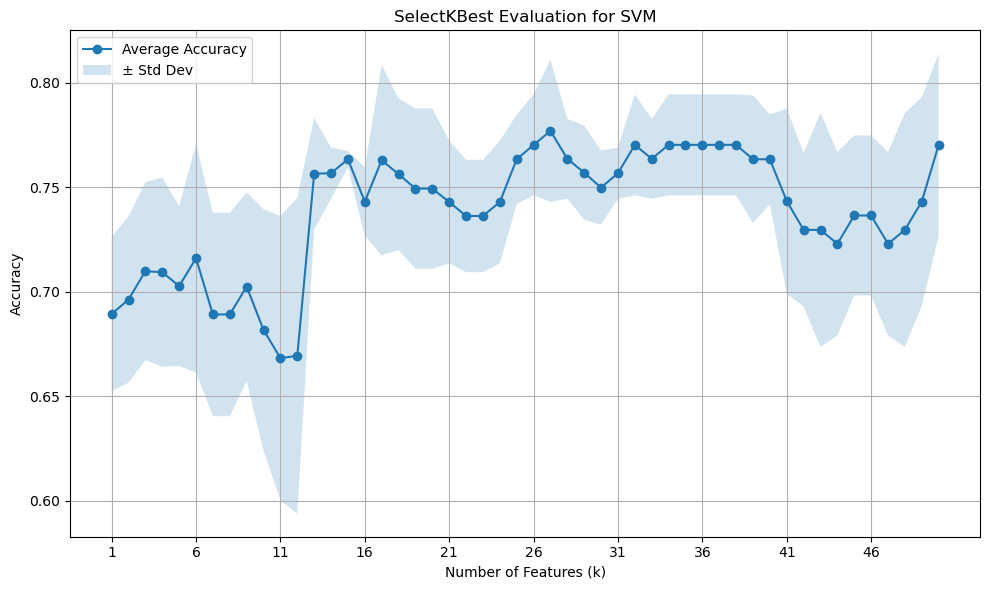


Evaluating LogisticRegression...


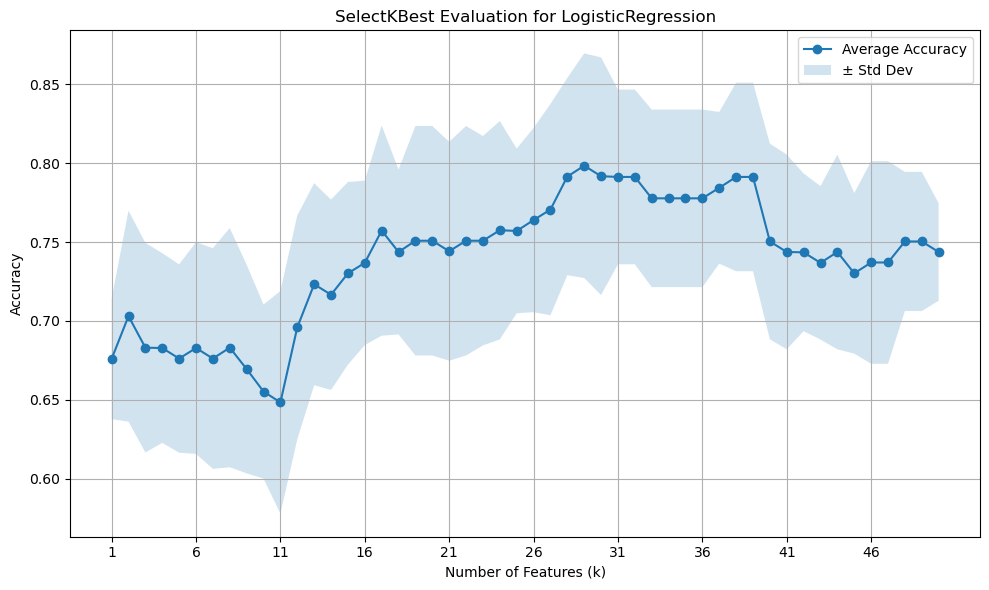


Evaluating LDA...


KeyboardInterrupt: 

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
# Model dictionary
models = {
    "kNN": (KNeighborsClassifier(), X_train_scaled),
    "SVM": (SVC(kernel="rbf"), X_train_scaled),
    "LogisticRegression": (LogisticRegression(max_iter=10000), X_train_scaled),
    "LDA": (LinearDiscriminantAnalysis(), X_train_scaled),	
    "QDA": (QuadraticDiscriminantAnalysis(), X_train_scaled),
    "DT": (DecisionTreeClassifier(), X_train_scaled),
    "NB": (GaussianNB(), X_train_scaled)
}

k_values = range(1, 51)
kf = StratifiedKFold(n_splits=5, shuffle=True)

# Result storage
results = {}

for model_name, (model, X_input) in models.items():
    print(f"\nEvaluating {model_name}...")
    average_accuracies = []
    std_accuracies = []

    for k in k_values:
        selector = SelectKBest(f_classif, k=k)
        X_selected = selector.fit_transform(X_input, y_train)
        accuracies = []

        for train_index, test_index in kf.split(X_selected, y_train):
            X_fold_train, X_fold_test = X_selected[train_index], X_selected[test_index]
            y_fold_train, y_fold_test = y_train.iloc[train_index], y_train.iloc[test_index]

            model.fit(X_fold_train, y_fold_train)
            y_pred = model.predict(X_fold_test)
            acc = accuracy_score(y_fold_test, y_pred)
            accuracies.append(acc)

        avg_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        average_accuracies.append(avg_acc)
        std_accuracies.append(std_acc)

    # Save results for plotting
    results[model_name] = {
        "avg": average_accuracies,
        "std": std_accuracies
    }

    # Plot
    upper = np.array(average_accuracies) + np.array(std_accuracies)
    lower = np.array(average_accuracies) - np.array(std_accuracies)

    plt.figure(figsize=(10, 6))
    plt.plot(list(k_values), average_accuracies, marker='o', label='Average Accuracy')
    plt.fill_between(list(k_values), upper, lower, alpha=0.2, label='± Std Dev')
    plt.title(f'SelectKBest Evaluation for {model_name}')
    plt.xlabel('Number of Features (k)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(list(k_values)[::5])
    plt.legend()
    plt.tight_layout()
    plt.show()

# Bepaal het beste k voor elk model
for model_name, (model_obj, X_input) in models.items():
    k_best = np.argmax(results[model_name]["avg"]) + 1
    print(f"{model_name} → beste k = {k_best}")



## Select k best features with greedy forward selection


Evaluating LDA...
Evaluating k = 1...
Evaluating k = 6...
Evaluating k = 11...
Evaluating k = 16...
Evaluating k = 21...
Evaluating k = 26...
Evaluating k = 31...
Evaluating k = 36...
Evaluating k = 41...
Evaluating k = 46...
Evaluating k = 51...
Evaluating k = 56...


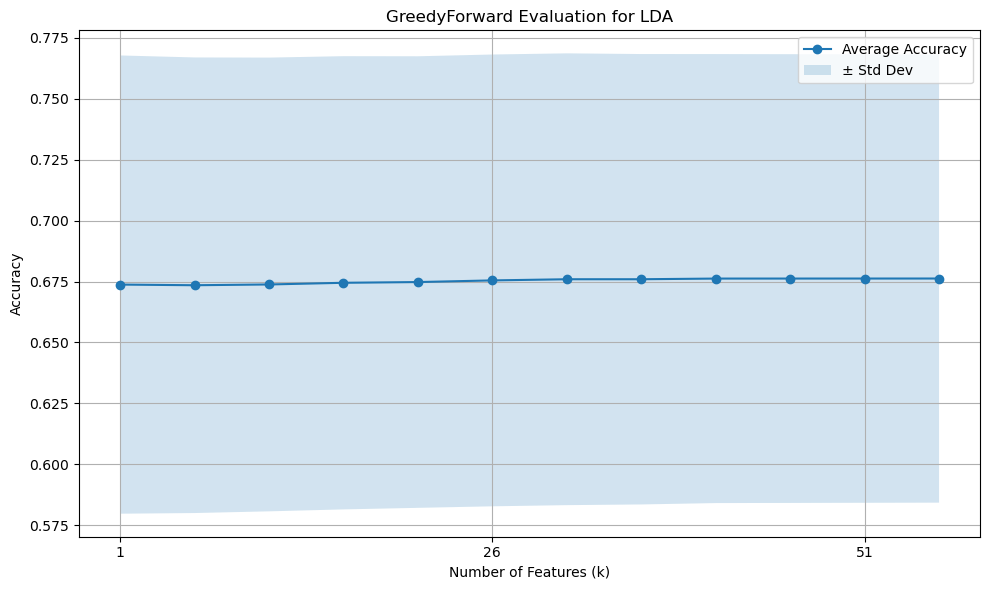


Evaluating QDA...
Evaluating k = 1...
Evaluating k = 6...
Evaluating k = 11...
Evaluating k = 16...
Evaluating k = 21...
Evaluating k = 26...
Evaluating k = 31...
Evaluating k = 36...
Evaluating k = 41...
Evaluating k = 46...
Evaluating k = 51...
Evaluating k = 56...


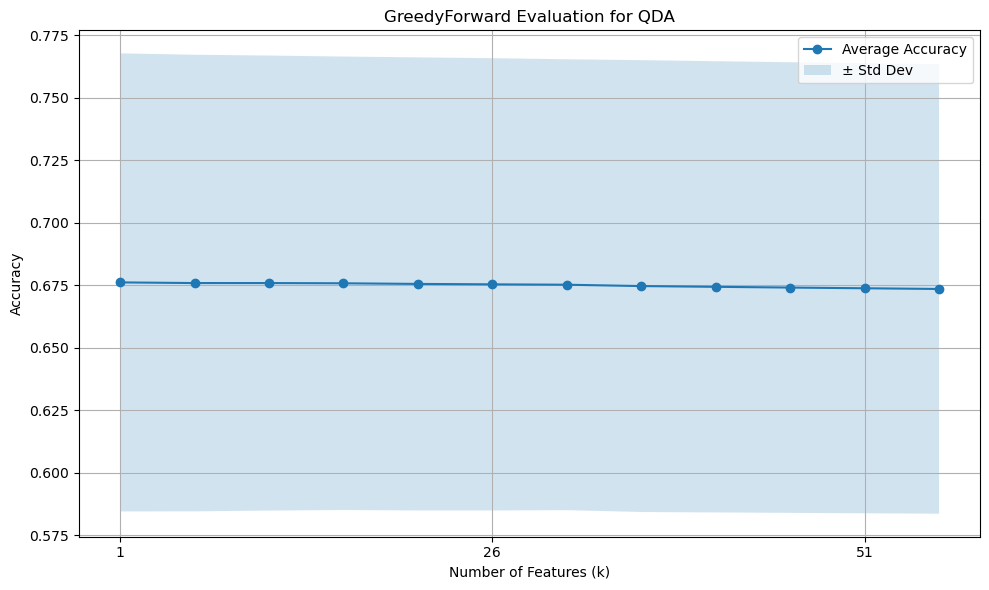

LDA → beste k = 60
QDA → beste k = 5


In [226]:
models = {
    "LDA": (LinearDiscriminantAnalysis(), X_train_scaled),
    "QDA": (QuadraticDiscriminantAnalysis(reg_param=0.01), X_train_scaled)
}
step = 5
k_values = range(1,61,step)

for model_name, (model, X_input) in models.items():
    print(f"\nEvaluating {model_name}...")
    average_accuracies = []
    std_accuracies = []
    for k in k_values:
        print(f"Evaluating k = {k}...")
        for train_idx, test_idx in kf.split(X_train_scaled, y_train):
        
            X_fold_train, X_fold_test = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[test_idx]
            y_fold_train, y_fold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

            selected_features, X_train_reduced, X_test_reduced = greedy_forward_selection(X_fold_train, y_fold_train, X_fold_test, y_fold_test, k, model)

            # Train the model on the reduced training set
            model.fit(X_train_reduced, y_fold_train)
            
            # Evaluate the model on the reduced test set
            y_pred = model.predict(X_test_reduced)
            acc = accuracy_score(y_fold_test, y_pred)
            accuracies.append(acc)

        avg_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        average_accuracies.append(avg_acc)
        std_accuracies.append(std_acc)

    # Save results for plotting
    results[model_name] = {
        "avg": average_accuracies,
        "std": std_accuracies}

    # Plot
    upper = np.array(average_accuracies) + np.array(std_accuracies)
    lower = np.array(average_accuracies) - np.array(std_accuracies)

    plt.figure(figsize=(10, 6))
    plt.plot(list(k_values), average_accuracies, marker='o', label='Average Accuracy')
    plt.fill_between(list(k_values), upper, lower, alpha=0.2, label='± Std Dev')
    plt.title(f'GreedyForward Evaluation for {model_name}')
    plt.xlabel('Number of Features (k)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(list(k_values)[::5])
    plt.legend()
    plt.tight_layout()
    plt.show()

# Bepaal het beste k voor elk model
for model_name, (model_obj, X_input) in models.items():
    k_best = (np.argmax(results[model_name]["avg"]) + 1)*step
    print(f"{model_name} → beste k = {k_best}")



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

kbest_selector = SelectKBest(f_classif, k=40)
X_train_kbest = kbest_selector.fit_transform(X_train_scaled, y_train)

models = {
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "LogisticRegression": LogisticRegression(max_iter=100000),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100)
}

# Initialiseer een dictionary voor de resultaten
cv_results = {
    "accuracy": {},
    "f1": {},
    "recall": {}
}

# Train de modellen met cross-validatie voor verschillende scoringsparameters
for model_name, model in models.items():
    # Accuracy
    accuracy_scores = cross_val_score(model, X_train_kbest, y_train, cv=5, scoring='accuracy')
    cv_results['accuracy'][model_name] = {
        'mean_score': np.mean(accuracy_scores),
    }
    
    # F1-score
    f1_scores = cross_val_score(model, X_train_kbest, y_train, cv=5, scoring='f1')
    cv_results['f1'][model_name] = {
        'mean_score': np.mean(f1_scores),
    }
    
    # Recall
    recall_scores = cross_val_score(model, X_train_kbest, y_train, cv=5, scoring='recall')
    cv_results['recall'][model_name] = {
        'mean_score': np.mean(recall_scores),
    }


# Initialiseer een lijst om de resultaten in te voeren
table_data = []

# Voeg de resultaten toe aan de lijst
for metric in ['accuracy', 'f1', 'recall']:
    for model_name, results in cv_results[metric].items():
        table_data.append({
            'Model': model_name,
            'Metric': metric.capitalize(),
            'Mean Score': results['mean_score']
        })

# Maak een DataFrame van de lijst
cv_results_df = pd.DataFrame(table_data)

# Pivot de DataFrame voor een overzichtelijke tabel
cv_results_pivot = cv_results_df.pivot_table(index='Model', columns='Metric', values=['Mean Score'])

# Weergeven van de tabel
print(cv_results_pivot)


                       Mean Score                    
Metric                   Accuracy        F1    Recall
Model                                                
LDA                      0.721839  0.709320  0.666667
LogisticRegression       0.742299  0.735858  0.706667
QDA                      0.804138  0.792976  0.746667
RandomForestClassifier   0.722529  0.727853  0.733333
SVM                      0.742989  0.737285  0.720000
kNN                      0.729425  0.705916  0.653333


## Basic classifiers
### Linear Discriminant Analysis

In [242]:
# Select features
# GreedyForward Selection

lda = LinearDiscriminantAnalysis()
features_selected, X_train_reduced, X_test_reduced = greedy_forward_selection(X_train_scaled, y_train, X_test_scaled, y_test, k=70, model=lda)

c:\Users\liann\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


In [243]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Define parameter grids for solvers
param_grid = {
    'svd': {'solver': ['svd'], 'shrinkage': [None]},  # For 'svd' solver
    'lsqr': {'solver': ['lsqr'], 'shrinkage': [None, 'auto'] + list(np.linspace(0, 1, 5))},  # For 'lsqr' solver
    'eigen': {'solver': ['eigen'], 'shrinkage': [None, 'auto'] + list(np.linspace(0, 1, 5))}  # For 'eigen' solver
}

# Initialize variables to track the best solver
best_score = -float('inf')
best_solver, best_params = None, None
best_f1, best_recall, best_accuracy = None, None, None

# Iterate over each solver and perform RandomizedSearchCV
for solver, grid in param_grid.items():
    search = RandomizedSearchCV(
        lda, 
        param_distributions=grid, 
        n_iter=5, 
        scoring='accuracy', 
        cv=5 
    )
    search.fit(X_train_reduced, y_train)

    # Predict and evaluate on the test set
    y_pred = search.predict(X_test_reduced)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Update the best solver based on the best score
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_solver = solver
        best_params = search.best_params_
        best_f1 = f1
        best_recall = recall
        best_accuracy = accuracy

# Output the best solver and its metrics
print(f"Best solver: {best_solver}")
print(f"Best parameters for {best_solver}: {best_params}")
print(f"best cross-validation score: {best_score}")
print(f"Test set accuracy: {best_accuracy}")
print(f"Test set F1 score: {best_f1}")
print(f"Test set recall score: {best_recall}")


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=5. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best solver: lsqr
Best parameters for lsqr: {'solver': 'lsqr', 'shrinkage': 'auto'}
best cross-validation score: 0.8241379310344827
Test set accuracy: 0.7105263157894737
Test set F1 score: 0.717948717948718
Test set recall score: 0.7368421052631579


### Quadratic Discriminant Analysis

In [233]:
# Feature selection using Greedy Forward
# Initialize the Quadratic Discriminant Analysis model
qda = QuadraticDiscriminantAnalysis()
# Perform Greedy Forward Selection
features_selected, X_train_reduced, X_test_reduced = greedy_forward_selection(X_train_scaled, y_train, X_test_scaled, y_test, k=5, model=qda)

c:\Users\liann\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


In [234]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import numpy as np


# Define parameter grid for QDA (since QDA doesn't have shrinkage, we'll focus on other parameters)
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],  # QDA solvers
    'reg_param': np.linspace(0, 1, 5)  # Regularization parameter for QDA
}

# Initialize variables to track the best solver
best_score = -float('inf')
best_solver, best_params = None, None
best_f1, best_recall, best_accuracy = None, None, None

# Iterate over each solver and perform RandomizedSearchCV
for solver in param_grid['solver']:
    # Update the grid for each solver
    grid = {key: value for key, value in param_grid.items() if key != 'solver'}
    
    search = RandomizedSearchCV(
        qda, 
        param_distributions=grid, 
        n_iter=5, 
        scoring='accuracy', 
        cv=5, 
    )
    search.fit(X_train_reduced, y_train)

    # Predict and evaluate on the test set
    y_pred = search.predict(X_test_reduced)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Update the best solver based on the best score
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_solver = solver
        best_params = search.best_params_
        best_f1 = f1
        best_recall = recall
        best_accuracy = accuracy

# Output the best solver and its metrics
print(f"Best solver: {best_solver}")
print(f"Best parameters for {best_solver}: {best_params}")
print(f"best cross-validation score: {best_score}")
print(f"Test set accuracy: {best_accuracy}")
print(f"Test set F1 score: {best_f1}")
print(f"Test set recall score: {best_recall}")

Best solver: svd
Best parameters for svd: {'reg_param': np.float64(0.0)}
best cross-validation score: 0.6960919540229884
Test set accuracy: 0.5
Test set F1 score: 0.4864864864864865
Test set recall score: 0.47368421052631576
